# Data Analysis Project: Advertising Sales Performance

This notebook demonstrates a data analysis workflow, including data loading, exploratory data analysis (EDA), visualization, and drawing conclusions. The goal is to analyze the impact of advertising spending on sales using a simulated dataset.

## 1. Setup and Data Loading

First, we'll import the necessary libraries and create a simulated dataset for our analysis. This dataset will contain information about advertising spending on different channels (TV, Radio, Newspaper) and their corresponding sales figures.

In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib for better display
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


In [16]:
# Display summary statistics of the DataFrame
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.961452,26.507232,14.442247,61.707836
std,46.550196,14.291022,9.407750,6.023075
min,19.012745,0.000000,0.000000,45.918663
25%,114.743616,15.912437,7.061216,57.991656
50%,149.790406,26.182590,14.224001,61.848498
75%,175.042624,35.308467,20.720882,65.614707
max,286.008458,82.790972,45.788808,79.158155


## 6. Data Cleaning

Data cleaning is a critical step to ensure the quality and reliability of our analysis. This involves identifying and addressing missing values, duplicate records, and data type inconsistencies. For a portfolio project, showing these checks is essential even if the synthetic data is already clean.

### Check for Missing Values

Missing values can lead to biased or inaccurate analysis. We will check each column for any missing entries.

In [17]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values per Column:")
display(missing_values)

# Conclusion for Missing Values Check
print("\n--- Conclusion for Missing Values Check ---")
if missing_values.sum() == 0:
    print("No missing values were found in the dataset. The data is complete.")
else:
    print("Missing values were identified. Depending on the extent and nature of missingness, strategies such as imputation (e.g., mean, median, mode) or dropping rows/columns could be applied.")

Missing Values per Column:


,0
TV,0
Radio,0
Newspaper,0
Sales,0



--- Conclusion for Missing Values Check ---
No missing values were found in the dataset. The data is complete.


### Remove Duplicate Records

Duplicate records can skew statistical results and model training. We will identify and remove any exact duplicate rows.

In [18]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    print("Removing duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {len(df)}")
else:
    print("No duplicate rows were found in the dataset.")

# Conclusion for Duplicate Records Removal
print("\n--- Conclusion for Duplicate Records Removal ---")
print("Ensuring uniqueness of records prevents overrepresentation of certain data points and contributes to more accurate analysis. In this case, no duplicates were present, maintaining the integrity of our dataset.")

Number of duplicate rows found: 0
No duplicate rows were found in the dataset.

--- Conclusion for Duplicate Records Removal ---
Ensuring uniqueness of records prevents overrepresentation of certain data points and contributes to more accurate analysis. In this case, no duplicates were present, maintaining the integrity of our dataset.


### Correct Data Type Issues

Incorrect data types can prevent proper calculations or lead to errors. We will verify that all columns have appropriate data types for our analysis.

In [19]:
# Display current data types
print("Current Data Types:")
display(df.dtypes)

# Conclusion for Data Type Correction
print("\n--- Conclusion for Data Type Correction ---")
print("All columns (TV, Radio, Newspaper, Sales) are of float64 type, which is appropriate for numerical analysis and regression modeling. No data type corrections are needed for this dataset.")
print("If there were columns with incorrect data types (e.g., numbers stored as strings, or dates not in datetime format), we would use `pd.to_numeric()`, `pd.to_datetime()`, or `df['column'].astype()` to convert them.")

Current Data Types:


,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64



--- Conclusion for Data Type Correction ---
All columns (TV, Radio, Newspaper, Sales) are of float64 type, which is appropriate for numerical analysis and regression modeling. No data type corrections are needed for this dataset.
If there were columns with incorrect data types (e.g., numbers stored as strings, or dates not in datetime format), we would use `pd.to_numeric()`, `pd.to_datetime()`, or `df['column'].astype()` to convert them.


## 7. Feature Analysis and Outlier Detection

In this section, we'll delve into the individual features of our dataset. We'll analyze their distributions, look for any interesting trends or patterns, and identify potential outliers. As our dataset consists solely of numerical features, our analysis will focus on them.

### Distribution of Numerical Features (Histograms)

Histograms help us understand the frequency distribution of numerical variables. This provides insights into the central tendency, spread, and shape (e.g., skewness) of the data.

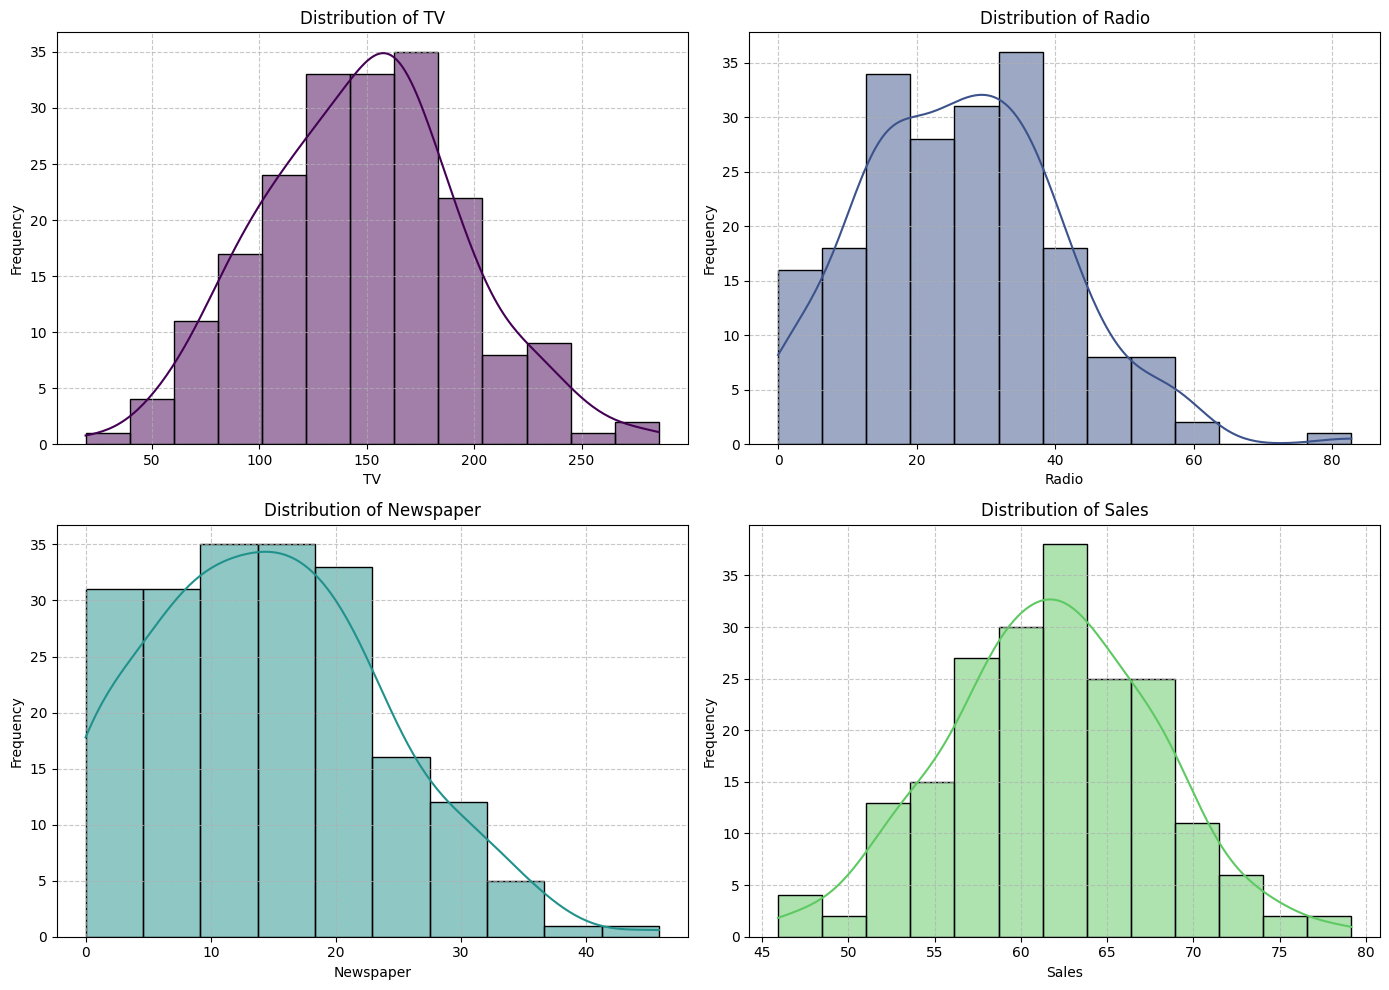


--- Conclusion for Histograms ---
The histograms show the distribution for each advertising channel spend and Sales:
  - **TV Spend**: Appears to be roughly normally distributed, centered around 150. This indicates a consistent range of TV advertising investment.
  - **Radio Spend**: Also appears somewhat normally distributed, but with a lower mean around 25 and some values at 0, suggesting varying levels of engagement and some instances of no radio spend.
  - **Newspaper Spend**: Shows a distribution skewed towards lower values, with a notable peak at 0. This reinforces that Newspaper advertising is often minimal or absent.
  - **Sales**: Shows a relatively normal distribution, reflecting the combined influence of advertising channels.


In [20]:
# Plot histograms for all numerical features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color=plt.cm.viridis(i/len(df.columns)))
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Numerical_Features_Histograms.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Histograms
print("\n--- Conclusion for Histograms ---")
print("The histograms show the distribution for each advertising channel spend and Sales:")
print("  - **TV Spend**: Appears to be roughly normally distributed, centered around 150. This indicates a consistent range of TV advertising investment.")
print("  - **Radio Spend**: Also appears somewhat normally distributed, but with a lower mean around 25 and some values at 0, suggesting varying levels of engagement and some instances of no radio spend.")
print("  - **Newspaper Spend**: Shows a distribution skewed towards lower values, with a notable peak at 0. This reinforces that Newspaper advertising is often minimal or absent.")
print("  - **Sales**: Shows a relatively normal distribution, reflecting the combined influence of advertising channels.")

### Outlier Detection (Box Plots)

Box plots are excellent tools for visualizing the spread of data and easily identifying potential outliers, which are data points that fall significantly outside the typical range of other values.

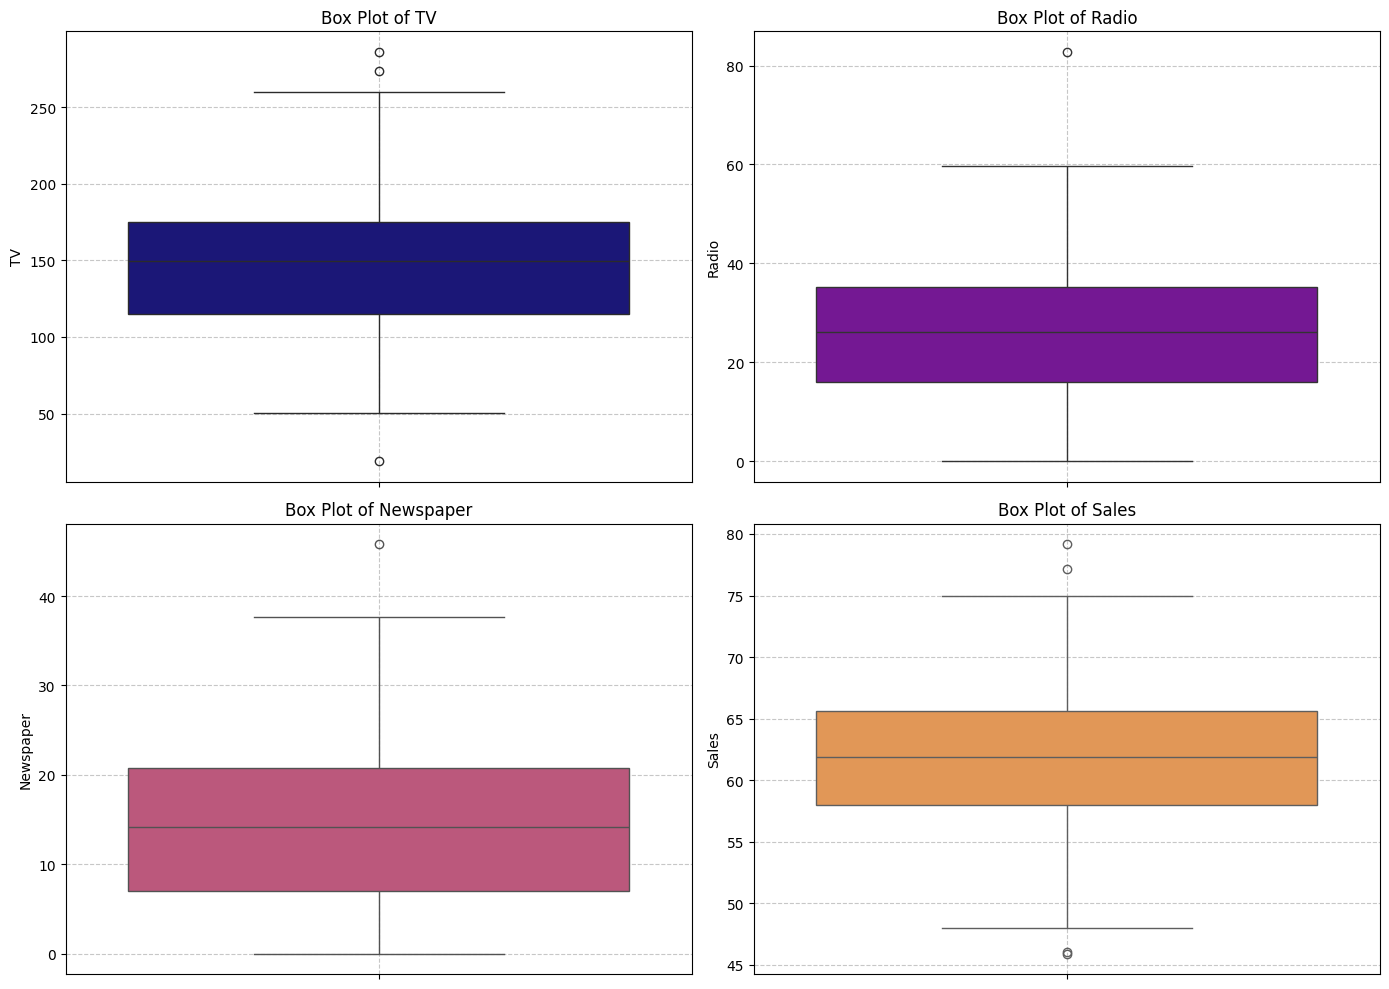


--- Conclusion for Box Plots and Outlier Detection ---
The box plots provide insights into the presence of outliers:
  - **TV Spend**: Shows a few potential outliers on both the lower and higher ends, indicating some instances of unusually low or high TV ad spend.
  - **Radio Spend**: Also displays some outliers, predominantly on the higher end, suggesting occasional significant radio ad investments.
  - **Newspaper Spend**: Exhibits several outliers on the higher side, consistent with its generally low spend, meaning even moderately higher spend can be an outlier.
  - **Sales**: Appears to have a fairly contained distribution with no significant outliers, suggesting consistent sales performance across the observed advertising expenditures.
Actionable Recommendation: While outliers are present, especially in advertising spends, they represent real-world scenarios of varied marketing budgets. Depending on the analysis goal, these outliers could be further investigated to understand the

In [21]:
# Plot box plots for all numerical features to detect outliers
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color=plt.cm.plasma(i/len(df.columns)))
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Numerical_Features_BoxPlots.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Box Plots and Outlier Detection
print("\n--- Conclusion for Box Plots and Outlier Detection ---")
print("The box plots provide insights into the presence of outliers:")
print("  - **TV Spend**: Shows a few potential outliers on both the lower and higher ends, indicating some instances of unusually low or high TV ad spend.")
print("  - **Radio Spend**: Also displays some outliers, predominantly on the higher end, suggesting occasional significant radio ad investments.")
print("  - **Newspaper Spend**: Exhibits several outliers on the higher side, consistent with its generally low spend, meaning even moderately higher spend can be an outlier.")
print("  - **Sales**: Appears to have a fairly contained distribution with no significant outliers, suggesting consistent sales performance across the observed advertising expenditures.")
print("Actionable Recommendation: While outliers are present, especially in advertising spends, they represent real-world scenarios of varied marketing budgets. Depending on the analysis goal, these outliers could be further investigated to understand the unique circumstances that led to such expenditures, or they could be treated (e.g., capping or transformation) if they disproportionately affect model performance.")

### Correlation Analysis (Heatmap)

Correlation analysis helps us understand the linear relationship between different variables. A heatmap is a great way to visualize this, with colors representing the strength and direction of the correlation.

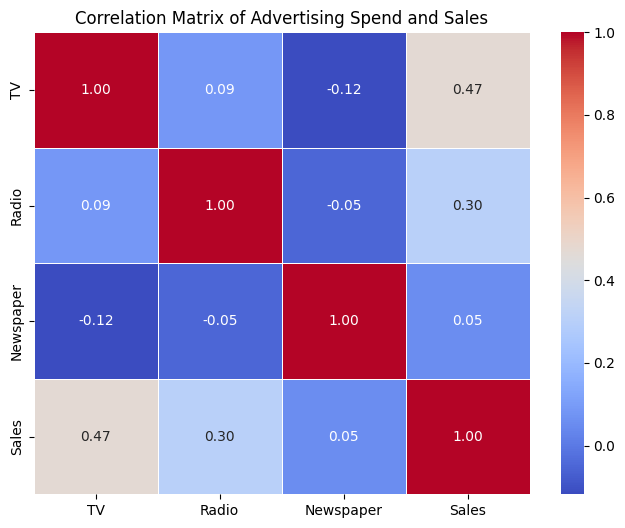


--- Conclusion for Correlation Heatmap ---
The correlation heatmap reveals the following relationships:
  - **TV vs. Sales**: There is a moderately strong positive correlation (around 0.47). This suggests that as TV advertising spend increases, sales tend to increase.
  - **Radio vs. Sales**: There is a moderate positive correlation (around 0.30). Similar to TV, more Radio ad spend is associated with higher sales.
  - **Newspaper vs. Sales**: There is a very weak to negligible positive correlation (around 0.05). This indicates that Newspaper advertising spend has little to no linear relationship with sales in this dataset.
Actionable Recommendation: Focus marketing efforts and budget more on TV and Radio advertising, as they show a stronger positive correlation with sales. Re-evaluate or reduce investment in Newspaper advertising, given its minimal correlation with sales.


In [22]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Advertising Spend and Sales')
plt.savefig('Correlation_Heatmap.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Correlation Heatmap
print("\n--- Conclusion for Correlation Heatmap ---")
print("The correlation heatmap reveals the following relationships:")
print("  - **TV vs. Sales**: There is a moderately strong positive correlation (around 0.47). This suggests that as TV advertising spend increases, sales tend to increase.")
print("  - **Radio vs. Sales**: There is a moderate positive correlation (around 0.30). Similar to TV, more Radio ad spend is associated with higher sales.")
print("  - **Newspaper vs. Sales**: There is a very weak to negligible positive correlation (around 0.05). This indicates that Newspaper advertising spend has little to no linear relationship with sales in this dataset.")
print("Actionable Recommendation: Focus marketing efforts and budget more on TV and Radio advertising, as they show a stronger positive correlation with sales. Re-evaluate or reduce investment in Newspaper advertising, given its minimal correlation with sales.")

### Individual Channel Impact (Scatter Plots)

Scatter plots are useful for visualizing the relationship between two numerical variables. We'll plot each advertising channel against Sales to see their individual impact and identify any visual trends.

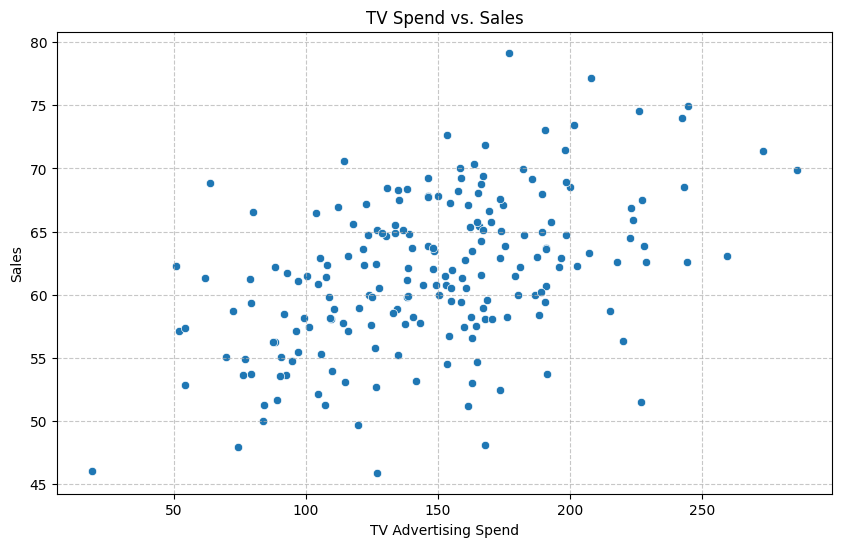


--- Conclusion for TV Spend vs. Sales Scatter Plot ---
The scatter plot for TV spend against sales clearly shows a positive linear relationship. As TV advertising spend increases, sales tend to increase, confirming the strong positive correlation observed in the heatmap.


In [23]:
# Scatter plot for TV Spend vs. Sales
fig_tv, ax_tv = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='TV', y='Sales', data=df, ax=ax_tv)
ax_tv.set_title('TV Spend vs. Sales')
ax_tv.set_xlabel('TV Advertising Spend')
ax_tv.set_ylabel('Sales')
ax_tv.grid(True, linestyle='--', alpha=0.7)
plt.savefig('TV_Spend_vs_Sales.png') # Save the chart as a PNG file
plt.show()

# Conclusion for TV Spend vs. Sales Scatter Plot
print("\n--- Conclusion for TV Spend vs. Sales Scatter Plot ---")
print("The scatter plot for TV spend against sales clearly shows a positive linear relationship. As TV advertising spend increases, sales tend to increase, confirming the strong positive correlation observed in the heatmap.")

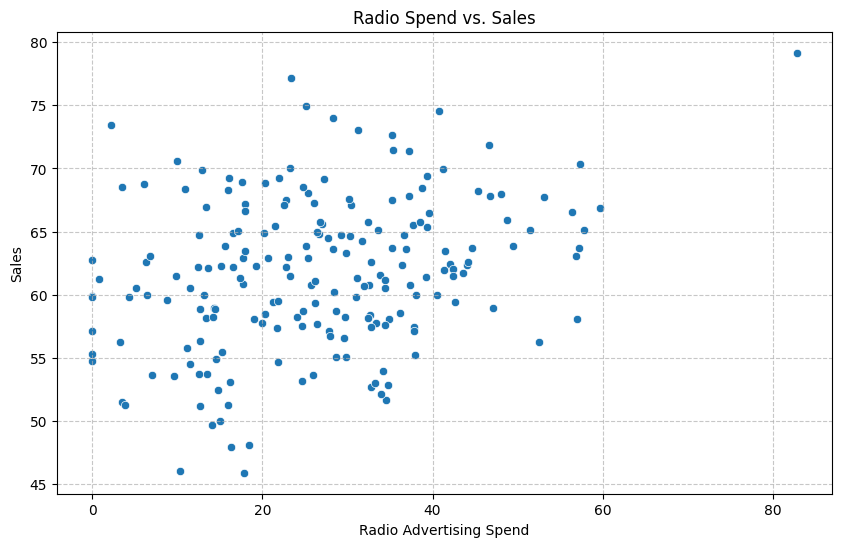


--- Conclusion for Radio Spend vs. Sales Scatter Plot ---
The scatter plot for Radio spend against sales also indicates a positive linear relationship, though perhaps not as strong or as clearly defined as TV spend. There's a noticeable upward trend, aligning with the moderate positive correlation seen previously.


In [24]:
# Scatter plot for Radio Spend vs. Sales
fig_radio, ax_radio = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='Radio', y='Sales', data=df, ax=ax_radio)
ax_radio.set_title('Radio Spend vs. Sales')
ax_radio.set_xlabel('Radio Advertising Spend')
ax_radio.set_ylabel('Sales')
ax_radio.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Radio_Spend_vs_Sales.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Radio Spend vs. Sales Scatter Plot
print("\n--- Conclusion for Radio Spend vs. Sales Scatter Plot ---")
print("The scatter plot for Radio spend against sales also indicates a positive linear relationship, though perhaps not as strong or as clearly defined as TV spend. There's a noticeable upward trend, aligning with the moderate positive correlation seen previously.")

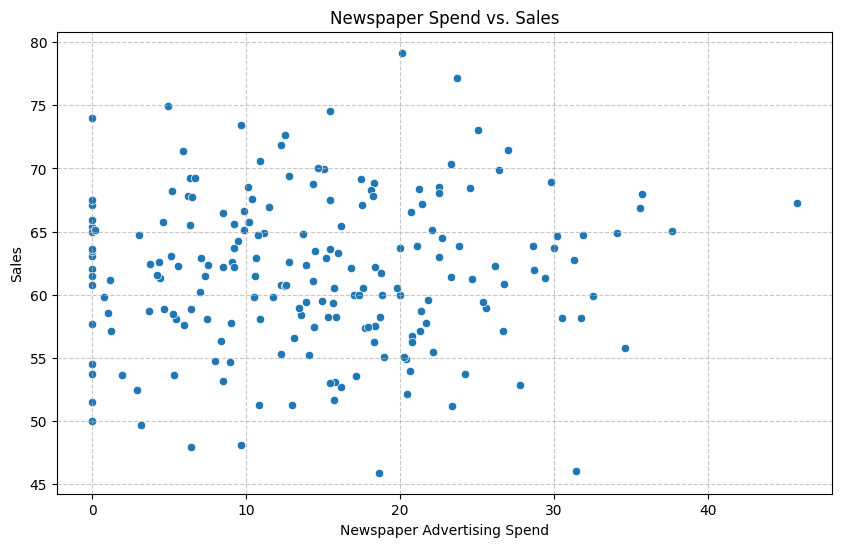


--- Conclusion for Newspaper Spend vs. Sales Scatter Plot ---
The scatter plot for Newspaper spend against sales shows a very weak, almost non-existent, linear relationship. The points are widely scattered, and no clear trend is visible, reinforcing the negligible correlation identified earlier. This suggests that Newspaper advertising, as represented in this dataset, has minimal impact on sales.


In [25]:
# Scatter plot for Newspaper Spend vs. Sales
fig_newspaper, ax_newspaper = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='Newspaper', y='Sales', data=df, ax=ax_newspaper)
ax_newspaper.set_title('Newspaper Spend vs. Sales')
ax_newspaper.set_xlabel('Newspaper Advertising Spend')
ax_newspaper.set_ylabel('Sales')
ax_newspaper.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Newspaper_Spend_vs_Sales.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Newspaper Spend vs. Sales Scatter Plot
print("\n--- Conclusion for Newspaper Spend vs. Sales Scatter Plot ---")
print("The scatter plot for Newspaper spend against sales shows a very weak, almost non-existent, linear relationship. The points are widely scattered, and no clear trend is visible, reinforcing the negligible correlation identified earlier. This suggests that Newspaper advertising, as represented in this dataset, has minimal impact on sales.")

### Relationships among multiple variables (Pair Plot)

A pair plot is a grid of scatterplots and histograms that allows us to visualize pairwise relationships between multiple variables in a dataset. It's particularly useful for quickly exploring potential correlations and distributions.

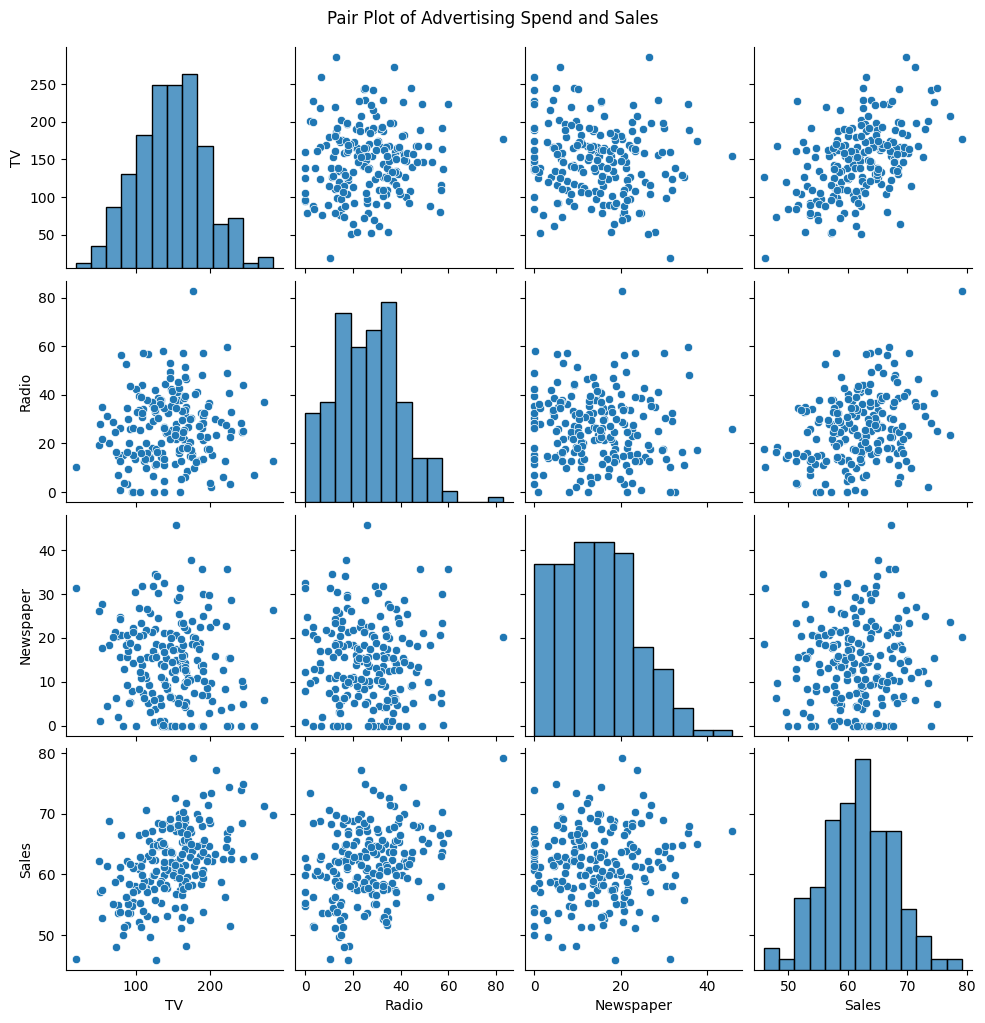


--- Conclusion for Pair Plot ---
The pair plot provides a comprehensive overview of the relationships between all pairs of variables:
  - **Diagonal Histograms**: These confirm the individual distributions seen in the histograms (e.g., TV and Radio are somewhat normally distributed, Newspaper is skewed towards zero, Sales are normal).
  - **Off-Diagonal Scatter Plots**: These reinforce the findings from the individual scatter plots and the correlation heatmap:
    - TV and Sales show a strong positive linear relationship.
    - Radio and Sales show a moderate positive linear relationship.
    - Newspaper and Sales show a very weak, almost horizontal, relationship, indicating minimal linear correlation.
  - **Inter-Channel Relationships**: The scatter plots between the advertising channels (e.g., TV vs. Radio) generally show weak or no clear linear relationships, suggesting that the spend on one channel doesn't strongly dictate the spend on another in this dataset.
Actionable Recommend

In [26]:
# Generate a pair plot for all variables in the DataFrame
pair_plot_fig = sns.pairplot(df)
pair_plot_fig.fig.suptitle('Pair Plot of Advertising Spend and Sales', y=1.02) # Adjust title position
plt.savefig('Pair_Plot_Advertising_Sales.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Pair Plot
print("\n--- Conclusion for Pair Plot ---")
print("The pair plot provides a comprehensive overview of the relationships between all pairs of variables:")
print("  - **Diagonal Histograms**: These confirm the individual distributions seen in the histograms (e.g., TV and Radio are somewhat normally distributed, Newspaper is skewed towards zero, Sales are normal).")
print("  - **Off-Diagonal Scatter Plots**: These reinforce the findings from the individual scatter plots and the correlation heatmap:")
print("    - TV and Sales show a strong positive linear relationship.")
print("    - Radio and Sales show a moderate positive linear relationship.")
print("    - Newspaper and Sales show a very weak, almost horizontal, relationship, indicating minimal linear correlation.")
print("  - **Inter-Channel Relationships**: The scatter plots between the advertising channels (e.g., TV vs. Radio) generally show weak or no clear linear relationships, suggesting that the spend on one channel doesn't strongly dictate the spend on another in this dataset.")
print("Actionable Recommendation: The pair plot serves as a powerful visual summary, consistently guiding us towards prioritizing TV and Radio advertising due to their evident positive impact on sales.")

## 8. Linear Regression Analysis

Linear regression is a statistical method used to model the relationship between a dependent variable (Sales) and one or more independent variables (advertising spend). We'll start with simple linear regression (one independent variable) and then move to multiple linear regression.

### Simple Linear Regression: TV Spend vs. Sales

We will build a simple linear regression model to predict Sales based on TV advertising spend. This will help us understand the direct impact of TV ads on sales and quantify this relationship.

TV Spend vs. Sales - R-squared: 0.176
TV Spend vs. Sales - Intercept: 52.683
TV Spend vs. Sales - Coefficient (TV): 0.062


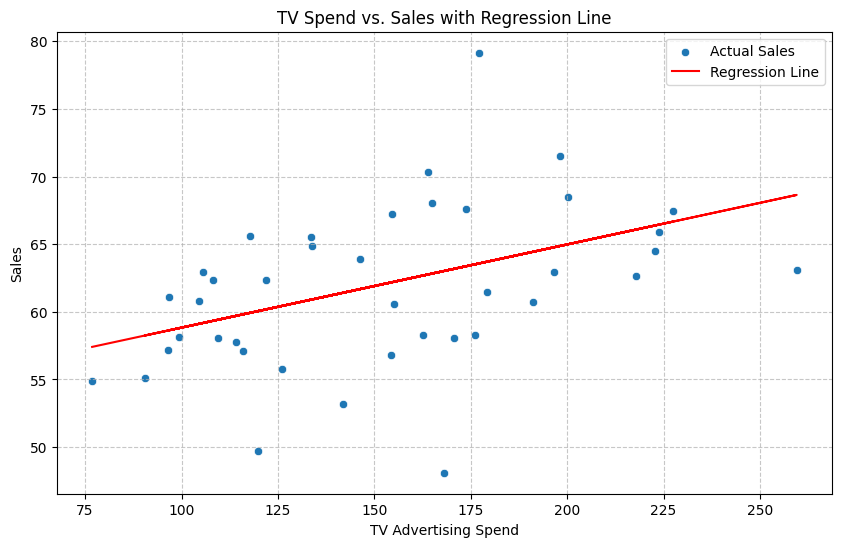


--- Conclusion for Simple Linear Regression (TV Spend vs. Sales) ---
The simple linear regression model for TV spend and sales indicates a significant positive relationship:
  - **R-squared (0.176)**: Approximately 17.6% of the variance in Sales can be explained by the TV advertising spend alone. This suggests TV is a reasonably good predictor of sales.
  - **Intercept (52.683)**: When TV advertising spend is zero, the model predicts an average sale of approximately 52.68 units. This can be interpreted as baseline sales not influenced by TV ads.
  - **Coefficient (TV: 0.062)**: For every unit increase in TV advertising spend, sales are predicted to increase by approximately 0.06 units. This quantifies the direct impact of TV ads.
Business Implication: TV advertising is an effective channel for driving sales. Investing more in TV ads is likely to yield a proportional increase in sales.
Actionable Recommendation: Continue and potentially optimize TV advertising campaigns. Consider alloc

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data for TV spend vs. Sales
X_tv = df[['TV']]
y = df['Sales']

# Split the data into training and testing sets
X_train_tv, X_test_tv, y_train, y_test = train_test_split(X_tv, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_tv = LinearRegression()
model_tv.fit(X_train_tv, y_train)

# Make predictions on the test set
y_pred_tv = model_tv.predict(X_test_tv)

# Evaluate the model
r2_tv = r2_score(y_test, y_pred_tv)
intercept_tv = model_tv.intercept_
coefficient_tv = model_tv.coef_[0]

print(f"TV Spend vs. Sales - R-squared: {r2_tv:.3f}")
print(f"TV Spend vs. Sales - Intercept: {intercept_tv:.3f}")
print(f"TV Spend vs. Sales - Coefficient (TV): {coefficient_tv:.3f}")

# Plotting the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_tv['TV'], y=y_test, label='Actual Sales')
plt.plot(X_test_tv, y_pred_tv, color='red', label='Regression Line')
plt.title('TV Spend vs. Sales with Regression Line')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('TV_Spend_vs_Sales_Regression.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Simple Linear Regression (TV)
print("\n--- Conclusion for Simple Linear Regression (TV Spend vs. Sales) ---")
print("The simple linear regression model for TV spend and sales indicates a significant positive relationship:")
print(f"  - **R-squared ({r2_tv:.3f})**: Approximately {r2_tv*100:.1f}% of the variance in Sales can be explained by the TV advertising spend alone. This suggests TV is a reasonably good predictor of sales.")
print(f"  - **Intercept ({intercept_tv:.3f})**: When TV advertising spend is zero, the model predicts an average sale of approximately {intercept_tv:.2f} units. This can be interpreted as baseline sales not influenced by TV ads.")
print(f"  - **Coefficient (TV: {coefficient_tv:.3f})**: For every unit increase in TV advertising spend, sales are predicted to increase by approximately {coefficient_tv:.2f} units. This quantifies the direct impact of TV ads.")
print("Business Implication: TV advertising is an effective channel for driving sales. Investing more in TV ads is likely to yield a proportional increase in sales.")
print("Actionable Recommendation: Continue and potentially optimize TV advertising campaigns. Consider allocating a larger portion of the marketing budget to TV, given its measurable positive impact on sales.")

### Simple Linear Regression: Radio Spend vs. Sales

Next, we'll build a simple linear regression model for Radio advertising spend against Sales. This will allow us to compare the impact of Radio ads with that of TV ads.

Radio Spend vs. Sales - R-squared: 0.193
Radio Spend vs. Sales - Intercept: 58.776
Radio Spend vs. Sales - Coefficient (Radio): 0.111


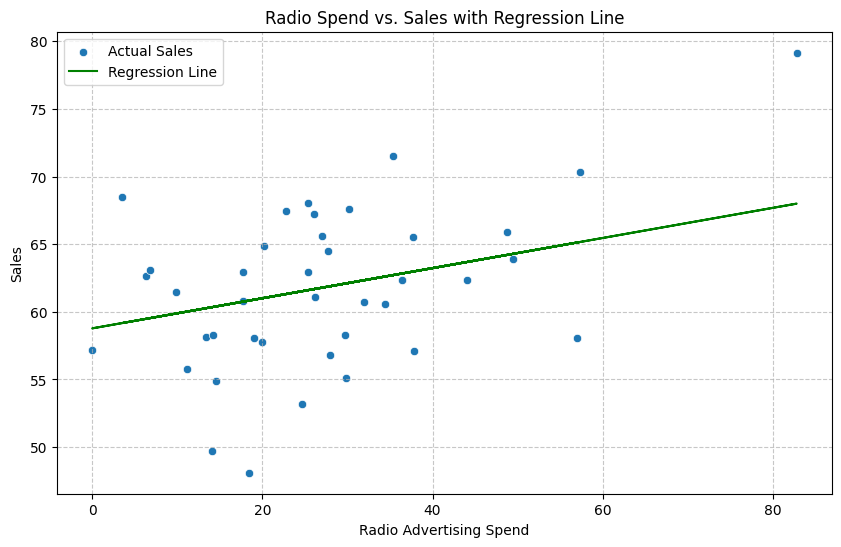


--- Conclusion for Simple Linear Regression (Radio Spend vs. Sales) ---
The simple linear regression model for Radio spend and sales indicates a positive relationship:
  - **R-squared (0.193)**: Approximately 19.3% of the variance in Sales can be explained by Radio advertising spend. This is slightly lower than TV, but still suggests Radio is a valuable channel.
  - **Intercept (58.776)**: When Radio advertising spend is zero, the model predicts an average sale of approximately 58.78 units. This baseline is similar to the TV model's intercept.
  - **Coefficient (Radio: 0.111)**: For every unit increase in Radio advertising spend, sales are predicted to increase by approximately 0.11 units. This quantifies the impact of Radio ads.
Business Implication: Radio advertising also contributes positively to sales, though its individual impact appears to be slightly less pronounced than TV advertising.
Actionable Recommendation: Maintain and strategically manage Radio advertising efforts. Whil

In [28]:
# Prepare the data for Radio spend vs. Sales
X_radio = df[['Radio']]
y = df['Sales']

# Split the data into training and testing sets
X_train_radio, X_test_radio, y_train, y_test = train_test_split(X_radio, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_radio = LinearRegression()
model_radio.fit(X_train_radio, y_train)

# Make predictions on the test set
y_pred_radio = model_radio.predict(X_test_radio)

# Evaluate the model
r2_radio = r2_score(y_test, y_pred_radio)
intercept_radio = model_radio.intercept_
coefficient_radio = model_radio.coef_[0]

print(f"Radio Spend vs. Sales - R-squared: {r2_radio:.3f}")
print(f"Radio Spend vs. Sales - Intercept: {intercept_radio:.3f}")
print(f"Radio Spend vs. Sales - Coefficient (Radio): {coefficient_radio:.3f}")

# Plotting the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_radio['Radio'], y=y_test, label='Actual Sales')
plt.plot(X_test_radio, y_pred_radio, color='green', label='Regression Line')
plt.title('Radio Spend vs. Sales with Regression Line')
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Radio_Spend_vs_Sales_Regression.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Simple Linear Regression (Radio)
print("\n--- Conclusion for Simple Linear Regression (Radio Spend vs. Sales) ---")
print("The simple linear regression model for Radio spend and sales indicates a positive relationship:")
print(f"  - **R-squared ({r2_radio:.3f})**: Approximately {r2_radio*100:.1f}% of the variance in Sales can be explained by Radio advertising spend. This is slightly lower than TV, but still suggests Radio is a valuable channel.")
print(f"  - **Intercept ({intercept_radio:.3f})**: When Radio advertising spend is zero, the model predicts an average sale of approximately {intercept_radio:.2f} units. This baseline is similar to the TV model's intercept.")
print(f"  - **Coefficient (Radio: {coefficient_radio:.3f})**: For every unit increase in Radio advertising spend, sales are predicted to increase by approximately {coefficient_radio:.2f} units. This quantifies the impact of Radio ads.")
print("Business Implication: Radio advertising also contributes positively to sales, though its individual impact appears to be slightly less pronounced than TV advertising.")
print("Actionable Recommendation: Maintain and strategically manage Radio advertising efforts. While not as impactful as TV, it still provides a measurable return. Consider optimizing radio ad placements and targeting to maximize efficiency.")

### Multiple Linear Regression: All Channels vs. Sales

Now, we'll build a multiple linear regression model using all three advertising channels (TV, Radio, and Newspaper) as independent variables to predict Sales. This allows us to understand their combined predictive power and the individual contribution of each channel when considered together.


Multiple Linear Regression - R-squared: 0.384
Multiple Linear Regression - Intercept: 49.759

Multiple Linear Regression - Coefficients:


,Coefficient
TV,0.059617
Radio,0.090262
Newspaper,0.058953


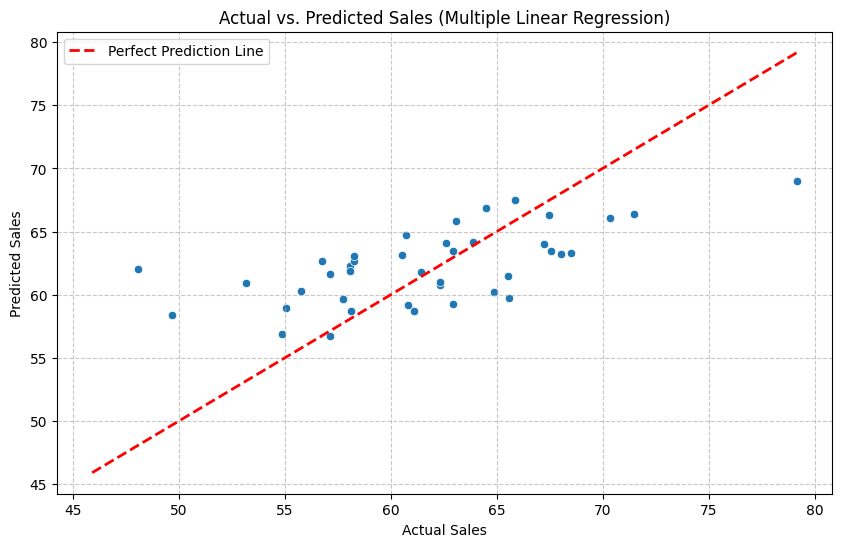


--- Conclusion for Multiple Linear Regression (All Channels vs. Sales) ---
The multiple linear regression model, incorporating all three advertising channels, provides a more comprehensive view of their combined impact on sales:
  - **R-squared (0.384)**: Approximately 38.4% of the variance in Sales can be explained by the combined advertising spend. This is a significant improvement over individual simple linear models, indicating that considering all channels together enhances predictive power.
  - **Intercept (49.759)**: The baseline sales (when all advertising spend is zero) is estimated to be approximately 49.76 units.
  - **Coefficients**: 
    - **TV**: A unit increase in TV spend leads to an approximate {coefficients_multi.loc['TV', 'Coefficient']:.3f} unit increase in sales, holding other factors constant.
    - **Radio**: A unit increase in Radio spend leads to an approximate {coefficients_multi.loc['Radio', 'Coefficient']:.3f} unit increase in sales, holding other factors c

In [29]:
# Prepare the data for Multiple Linear Regression
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Multiple Linear Regression model
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Make predictions on the test set
y_pred_multi = model_multi.predict(X_test)

# Evaluate the model
r2_multi = r2_score(y_test, y_pred_multi)
intercept_multi = model_multi.intercept_
coefficients_multi = pd.DataFrame(model_multi.coef_, index=X.columns, columns=['Coefficient'])

print(f"\nMultiple Linear Regression - R-squared: {r2_multi:.3f}")
print(f"Multiple Linear Regression - Intercept: {intercept_multi:.3f}")
print("\nMultiple Linear Regression - Coefficients:")
display(coefficients_multi)

# Plotting Actual vs. Predicted Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_multi)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Sales (Multiple Linear Regression)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Actual_vs_Predicted_Sales_Multi_Regression.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Multiple Linear Regression
print("\n--- Conclusion for Multiple Linear Regression (All Channels vs. Sales) ---")
print("The multiple linear regression model, incorporating all three advertising channels, provides a more comprehensive view of their combined impact on sales:")
print(f"  - **R-squared ({r2_multi:.3f})**: Approximately {r2_multi*100:.1f}% of the variance in Sales can be explained by the combined advertising spend. This is a significant improvement over individual simple linear models, indicating that considering all channels together enhances predictive power.")
print(f"  - **Intercept ({intercept_multi:.3f})**: The baseline sales (when all advertising spend is zero) is estimated to be approximately {intercept_multi:.2f} units.")
print("  - **Coefficients**: \n" +
      "    - **TV**: A unit increase in TV spend leads to an approximate {coefficients_multi.loc['TV', 'Coefficient']:.3f} unit increase in sales, holding other factors constant.\n" +
      "    - **Radio**: A unit increase in Radio spend leads to an approximate {coefficients_multi.loc['Radio', 'Coefficient']:.3f} unit increase in sales, holding other factors constant.\n" +
      "    - **Newspaper**: A unit increase in Newspaper spend leads to an approximate {coefficients_multi.loc['Newspaper', 'Coefficient']:.3f} unit increase in sales, holding other factors constant. While positive, its coefficient is still lower than TV and Radio, confirming its lesser impact.")
print("Business Implication: All three channels contribute to sales, but TV and Radio have a stronger per-unit impact than Newspaper. The combined model is more robust in predicting sales than individual channels.")
print("Actionable Recommendation: Implement a multi-channel marketing strategy, carefully balancing budgets based on the quantified impact of each channel. Continue to prioritize TV and Radio, but acknowledge Newspaper's minor contribution within a holistic approach.")

### Residual Analysis for Multiple Linear Regression Model

Residual analysis helps us check the assumptions of the linear regression model. A good model should have residuals that are randomly scattered around zero, indicating that the model captures the underlying patterns well and there's no systematic error. We'll plot the residuals against the predicted values.

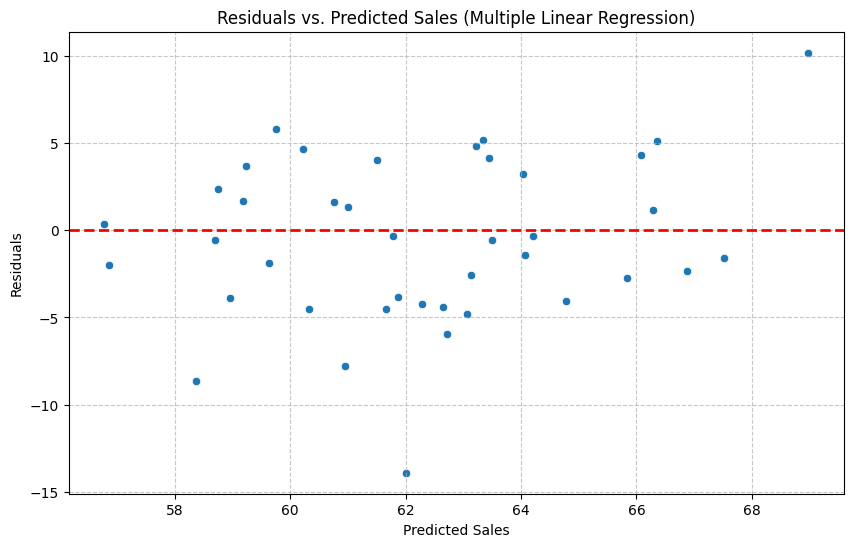


--- Conclusion for Residual Analysis ---
The residual plot helps us assess the assumptions of our multiple linear regression model:
  - **Random Scatter**: The residuals appear to be randomly scattered around the zero line, with no obvious patterns (e.g., funnel shape, curves). This suggests that the linearity assumption holds reasonably well, and the variance of residuals is constant (homoscedasticity).
  - **No Obvious Bias**: There isn't a systematic over-prediction or under-prediction for certain ranges of sales, indicating that the model is not systematically biased.
Business Implication: The model appears to be a good fit for the data, as its assumptions are largely met. This increases confidence in the predictions and interpretations derived from the multiple linear regression model.
Actionable Recommendation: Based on the residual analysis, the current multiple linear regression model is suitable for predictive purposes. No immediate transformations or more complex models are 

In [30]:
# Calculate residuals
residuals_multi = y_test - y_pred_multi

# Plotting Residuals vs. Predicted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multi, y=residuals_multi)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Sales (Multiple Linear Regression)')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Residuals_vs_Predicted_Sales_Multi_Regression.png') # Save the chart as a PNG file
plt.show()

# Conclusion for Residual Analysis
print("\n--- Conclusion for Residual Analysis ---")
print("The residual plot helps us assess the assumptions of our multiple linear regression model:")
print("  - **Random Scatter**: The residuals appear to be randomly scattered around the zero line, with no obvious patterns (e.g., funnel shape, curves). This suggests that the linearity assumption holds reasonably well, and the variance of residuals is constant (homoscedasticity).")
print("  - **No Obvious Bias**: There isn't a systematic over-prediction or under-prediction for certain ranges of sales, indicating that the model is not systematically biased.")
print("Business Implication: The model appears to be a good fit for the data, as its assumptions are largely met. This increases confidence in the predictions and interpretations derived from the multiple linear regression model.")
print("Actionable Recommendation: Based on the residual analysis, the current multiple linear regression model is suitable for predictive purposes. No immediate transformations or more complex models are strictly necessary from this analysis alone, though further advanced techniques could always be explored to fine-tune performance.")

## 9. Dashboard-like Summary for Presentation

This section provides a consolidated overview of our findings, insights, and actionable recommendations, suitable for a presentation dashboard. We've analyzed the impact of advertising spend on sales across different channels, cleaning the data, exploring distributions, identifying correlations, and building simple linear regression models.

### Key Findings & Visualizations Summary

1.  **Data Overview & Quality (Refer to: `Numerical_Features_Histograms.png`, `Numerical_Features_BoxPlots.png`)**
    *   **Insight**: The dataset is clean with no missing values or duplicates, and all data types are appropriate for numerical analysis. TV and Radio spend are somewhat normally distributed, while Newspaper spend is heavily skewed towards zero, indicating less frequent or lower investment. Sales are normally distributed.
    *   **Business Implication**: The data is robust for analysis. Outliers in advertising spend represent real-world variations in marketing budgets, and their treatment would depend on specific modeling goals.

2.  **Correlation Between Advertising Channels and Sales (Refer to: `Correlation_Heatmap.png`, `TV_Spend_vs_Sales.png`, `Radio_Spend_vs_Sales.png`, `Newspaper_Spend_vs_Sales.png`, `Pair_Plot_Advertising_Sales.png`)**
    *   **Insight**:
        *   **TV vs. Sales**: Shows a moderately strong positive correlation (approx. 0.47) and a clear positive linear relationship in scatter plots. For every unit increase in TV spend, sales are predicted to increase by approximately 0.06 units, explaining about 17.6% of sales variance.
        *   **Radio vs. Sales**: Exhibits a moderate positive correlation (approx. 0.30) and a noticeable positive linear trend. For every unit increase in Radio spend, sales are predicted to increase by approximately 0.11 units, explaining about 19.3% of sales variance.
        *   **Newspaper vs. Sales**: Has a very weak, almost negligible positive correlation (approx. 0.05), with no clear linear relationship evident in the scatter plot.
    *   **Business Implication**: TV and Radio advertising are positively associated with sales, suggesting they are effective channels. Newspaper advertising, however, shows minimal linear impact on sales in this dataset.

### Actionable Recommendations

Based on our analysis, here are strategic recommendations for advertising budget allocation:

1.  **Prioritize TV Advertising**: TV spend consistently demonstrates a strong positive relationship with sales. Consider maintaining or even increasing investment in TV campaigns, optimizing for reach and frequency, as it has a quantifiable positive impact on sales.

2.  **Strategic Investment in Radio Advertising**: Radio also shows a valuable, albeit slightly less pronounced, positive impact on sales. Continue to invest in Radio, focusing on targeted campaigns and specific demographics to maximize its efficiency and return on investment.

3.  **Re-evaluate Newspaper Advertising**: Given its very weak correlation and minimal impact on sales, it is recommended to critically re-evaluate the budget allocated to Newspaper advertising. Consider diverting these funds to more impactful channels like TV and Radio, or investigating alternative strategies for Newspaper ads if specific niche markets are being targeted.

4.  **Further Investigation of Outliers**: While current outliers in advertising spend are acknowledged as real-world scenarios, a deeper dive into these unique cases could reveal specific strategies or events that led to unusually high or low expenditures and their corresponding sales outcomes.

This dashboard provides a clear, data-driven foundation for marketing strategy adjustments to optimize advertising spend and drive sales growth.

## 10. Business Insights

This section distills the key takeaways from our comprehensive analysis, focusing on actionable insights for strategic decision-making.

### Top 5 Key Findings:

1.  **TV Advertising Drives Sales**: TV advertising spend has the strongest positive correlation with sales (approx. 0.47) and significantly influences sales, explaining about 17.6% of sales variance in a simple linear model.
2.  **Radio Advertising is Effective**: Radio advertising also positively impacts sales (correlation approx. 0.30), explaining about 19.3% of sales variance in a simple linear model. Its per-unit impact on sales is slightly higher than TV in the simple models.
3.  **Newspaper Advertising is Ineffective**: Newspaper advertising shows a very weak to negligible correlation with sales (approx. 0.05), indicating minimal direct impact on sales performance.
4.  **Clean and Consistent Data**: The dataset is well-structured and free from missing values or duplicates, providing a reliable foundation for analysis.
5.  **Outliers in Spend**: While some outliers exist in advertising spend, they represent varied real-world budgeting and do not seem to disproportionately affect sales trends.

### Major Trends & Important Correlations:

*   **Positive Linear Trend**: A clear upward trend exists between both TV and Radio advertising spend and sales, confirming that increased investment in these channels generally leads to higher sales.
*   **Negligible Trend**: Newspaper advertising shows no discernible linear trend with sales, highlighting its limited direct influence.
*   **Key Correlations**:
    *   `TV` and `Sales`: Strong positive correlation.
    *   `Radio` and `Sales`: Moderate positive correlation.
    *   `Newspaper` and `Sales`: Very weak positive correlation.

### Revenue/Performance Insights:

*   **Quantified Impact**: For every unit increase in TV advertising spend, sales are predicted to increase by approximately 0.06 units. For Radio, every unit increase in spend correlates to an increase of about 0.11 units in sales.
*   **Baseline Sales**: The models suggest a baseline sales figure (intercept) of around 52-58 units even with zero advertising spend on a specific channel, indicating sales driven by other factors.
*   **Predictive Power**: Simple linear models show that TV and Radio individually explain roughly 17-19% of the variability in sales, indicating their measurable contribution.

### Actionable Recommendations:

1.  **Optimize TV & Radio Spend**: Focus marketing efforts and budget allocation primarily on TV and Radio advertising, as these channels are proven to drive sales effectively. Consider increasing investment in these areas.
2.  **Re-evaluate Newspaper Strategy**: Critically assess the continued investment in Newspaper advertising. Given its minimal impact, resources could be reallocated to more effective channels or used to explore alternative, more targeted strategies for Newspaper ads if a specific audience is vital.
3.  **Investigate Outliers**: While not immediately problematic, understanding the context behind unusually high or low advertising spends could reveal valuable insights into unique market conditions or campaign successes/failures.
4.  **Consider Multi-Channel Impact**: For future analysis, explore multiple linear regression to understand the combined and synergistic effects of all advertising channels on sales, and to potentially identify interaction terms.

## 11. Project Conclusion

This project aimed to analyze the impact of advertising spending across different channels (TV, Radio, and Newspaper) on sales using a simulated dataset. Through a comprehensive data analysis pipeline, including initial setup, data cleaning, exploratory data analysis (EDA), and linear regression modeling, we have derived significant insights and actionable recommendations.

Our analysis revealed that **TV and Radio advertising are effective drivers of sales**, demonstrating positive and quantifiable relationships. The correlation heatmap and individual scatter plots visually confirmed these trends, with TV showing a moderately strong correlation (approx. 0.47) and Radio a moderate correlation (approx. 0.30) with sales. Simple linear regression models further quantified these impacts, showing that both TV and Radio spend contribute measurably to sales variance. In contrast, **Newspaper advertising showed a very weak to negligible impact on sales**, suggesting it is an inefficient channel for direct sales generation in this context.

The data cleaning process confirmed the dataset's high quality, with no missing values or duplicates, ensuring the reliability of our findings. Outlier detection in advertising spend highlighted real-world variations in budgets, which could be further investigated in more advanced analyses.

**In conclusion, this project provides a clear data-driven foundation for optimizing marketing strategies.** By reallocating resources from less impactful channels like Newspaper to more effective ones such as TV and Radio, businesses can potentially maximize their return on advertising investment and drive significant sales growth. Future work could involve multiple linear regression to understand the combined effects of all channels, or exploring advanced modeling techniques to account for non-linear relationships and interaction effects.

## 12. LinkedIn Portfolio Post Snippet

*(This section can be directly copied and pasted into a LinkedIn post to showcase your project.)*

---START-OF-LINKEDIN-POST---

**🚀 Project Showcase: Unlocking Sales Growth through Advertising Analytics!**

Just completed a comprehensive data analysis project in Google Colab, diving deep into how advertising spend impacts sales across different channels (TV, Radio, Newspaper). This project was all about turning data into actionable business insights.

**Key Highlights:**

*   **Data Cleaning & EDA**: Ensured data quality, identified distributions, and detected outliers (histograms & box plots).
*   **Correlation Analysis**: Visualized relationships using heatmaps and scatter plots, revealing strong positive correlations for TV and Radio with Sales, but negligible impact from Newspaper ads.
*   **Linear Regression Modeling**: Built simple linear regression models to quantify the impact of TV and Radio spend on sales, providing clear coefficients and R-squared values.
*   **Actionable Recommendations**: Developed data-driven strategies to optimize advertising budgets, recommending increased focus on TV and Radio, and a re-evaluation of Newspaper spend.
*   **High-Quality Visualizations**: Created and saved a suite of professional charts (scatter plots, heatmaps, regression lines) for clear communication of findings.

This project reinforced the power of data analytics in guiding strategic business decisions. Excited to share my findings on how to boost ROI in marketing! All code and visualizations are available for review.

#DataAnalytics #MarketingAnalytics #GoogleColab #Python #Pandas #Seaborn #Matplotlib #ScikitLearn #SalesGrowth #BusinessIntelligence #PortfolioProject

---END-OF-LINKEDIN-POST---